In [1]:
%load_ext autoreload
%autoreload 2

In [56]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from tqdm import tqdm

In [3]:
from ICMTSMTGuitarDataParam import *
from jupyter_audio_utils import *

# new bins

Previously, the bins had linear steps, disregarding the type and function of each parameters. Thus, an improvement was made, where the bins can be generated with 
custom steps. As of now, total of three types of steps are implemented: linear, logarithmic,
and exponential. 

In [4]:
PEDAL_DICT['compressor']['params']['threshold_db']

{'min': -60,
 'max': 10,
 'arange': <function pedalboard_utils.pow_range(lower: int, upper: int, step_size: int) -> numpy.ndarray>}

The bins are then generated using the provided range function for some step_size

[-60.         -59.39418551 -58.42135983 -56.85918225 -54.35061486
 -50.32232101 -43.85362837 -33.466108   -16.7856773   10.        ]


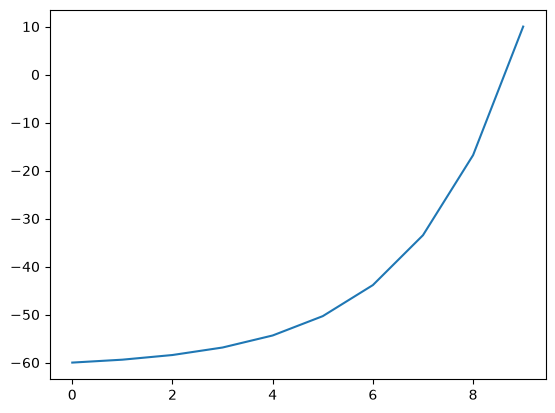

In [5]:
y = PEDAL_DICT_BINNED['compressor']['params']['threshold_db']
print(y)
plt.plot(np.arange(10), y)
plt.show()

In [6]:
mono = ICMTSMTGuitarDataMono(PEDAL_DICT_BINNED)
poly = ICMTSMTGuitarDataPoly(PEDAL_DICT_BINNED)

# new tokens

Previously, tokens were created with the following scheme: `<effect>:<param>:<value>`. Unique
token id was given for unique combination of the three variables. While a encoder-decoder 
model was able to learn and predict, non-randomly, what kinds of effects might have been 
present given a wet audio using the aforementioned tokenization scheme, there are two big 
problems. 

1. Inability to train the model on the order of pedals.
3. Explosion in the number of tokens. For the same effect for the same parameter, multiple tokens will be allocated for different possible values.

Thus, the new tokenization scheme, relying on self-attention layers of transformers to attend to previous tokens, decouples values, types of parameters, and types of effects altogether. The values are indices of the corresponding bin.

In [7]:
dry, wet, board_str = next(iter(poly))
play_audio(*dry)
play_audio(*wet)
print(board_str)

[]


In [8]:
# testing bounds of pedal parameters 
compressor = PEDAL_DICT["compressor"]
distortion = PEDAL_DICT["distortion"]
reverb = PEDAL_DICT["reverb"]
phaser = PEDAL_DICT["phaser"]
chorus = PEDAL_DICT["chorus"]

def test_bounds(pedal_dict): 
    pedal = pedal_dict['pedal'] 
    params = pedal_dict['params'] 
    
    min_args = {}
    max_args = {}

    for param, ranges in params.items(): 
        min_args[param] = ranges["min"]
        max_args[param] = ranges["max"]
    min_pedal = pedal(**min_args)
    max_pedal = pedal(**max_args)

    return min_pedal, max_pedal

waveform, sr = dry
for name, pedal in PEDAL_DICT.items():
    min_pedal, max_pedal = test_bounds(pedal)
    print(name)
    print(min_pedal)
    play_audio(torch.Tensor(min_pedal(waveform.numpy(), sr)), sr)
    print(max_pedal)
    play_audio(torch.Tensor(max_pedal(waveform.numpy(), sr)), sr)

compressor
<pedalboard.Compressor threshold_db=-60 ratio=1.1 attack_ms=1 release_ms=40 at 0x35ec2680>


<pedalboard.Compressor threshold_db=10 ratio=20 attack_ms=100 release_ms=400 at 0x3626de20>


distortion
<pedalboard.Distortion drive_db=0 at 0x362199c0>


<pedalboard.Distortion drive_db=45 at 0x36231190>


chorus
<pedalboard.Chorus rate_hz=0.1 depth=0.01 centre_delay_ms=5 feedback=0 mix=0 at 0x3416e970>


<pedalboard.Chorus rate_hz=8 depth=0.25 centre_delay_ms=25 feedback=0.4 mix=1 at 0x3416f080>


phaser
<pedalboard.Phaser rate_hz=0.1 depth=0.1 centre_frequency_hz=100 feedback=0 mix=0.5 at 0x34167f70>


<pedalboard.Phaser rate_hz=5 depth=1 centre_frequency_hz=2000 feedback=0.6 mix=1 at 0x34168510>


reverb
<pedalboard.Reverb room_size=0.1 damping=0.01 wet_level=0.01 dry_level=0.01 width=0.01 freeze_mode=0 at 0x3626bc60>


<pedalboard.Reverb room_size=1 damping=1 wet_level=1 dry_level=1 width=1 freeze_mode=0 at 0x36266630>


In [9]:
class PositionalEncoding(torch.nn.Module):
  """
  Sinusoidal positional encoding, which is added to input embeddings before
  they are processed with transformer layers.
  """

  def __init__(
    self,
    model_dim: int,  # the model's internal "dimension" or "hidden size"
    max_length: int = 1024,  # the maximum allowed sequence length for our transformer
  ):
    super().__init__()

    self.model_dim = model_dim
    self.max_length = max_length

    pe = torch.zeros(max_length, model_dim)
    position = torch.arange(0, max_length, dtype=torch.float).unsqueeze(1)

    scale = torch.exp(
      torch.arange(
          0, model_dim, 2, dtype=torch.float
      ) * (-math.log(10000.0) / model_dim)
    )
    pe[:, 0::2] = torch.sin(position * scale)
    pe[:, 1::2] = torch.cos(position * scale)

    pe = pe.unsqueeze(0)  # (1, max_length, model_dim)
    self.register_buffer('pe', pe)

  def forward(self, x: torch.Tensor):

    assert x.ndim == 3  # (n_batch, seq_len, model_dim)
    assert x.shape[1] <= self.max_length
    assert x.shape[2] == self.model_dim

    seq_len = x.size(1)
    x = x + self.pe[:, :seq_len]

    return x  # (n_batch, seq_len, model_dim)

def get_causal_mask(x: torch.Tensor):
  """
  A utility function for computing a causal attention mask given an input
  sequence. This mask will have shape (n_batch, 1, seq_len, seq_len), where
  seq_len is the sequence length of the input. We can think of this mask as a 
  square grid, where an entry at index [i, j] is True if we want to allow
  sequence position i to attend to sequence position j, and False otherwise.

  To prevent out transformer attention layers from "looking forward" in time,
  we will construct a mask such that the entry at index [i, j] will be False
  when i < j, and True otherwise.
  """
  assert x.ndim == 3  # (n_batch, seq_len, model_dim)
  n_batch, seq_len, model_dim = x.shape

  mask = torch.tril(
    torch.ones(seq_len, seq_len, dtype=torch.bool, device=x.device)
  )
  #mask = mask.unsqueeze(0).unsqueeze(0).expand(n_batch, 1, seq_len, seq_len)
  return mask  # (n_batch, 1, seq_len, seq_len)
        
class DecoderOnly(nn.Module): 
    def __init__(
        self, 
        num_vocab: int,
        d_model: int, 
        num_heads: int,
        num_layers: int,
        max_token_len: int,
        dropout: float = 0.1, 
        mult: int = 4, 
        activation: str = "relu", # or "gelu"
        batch_first: bool = True, # input and output tensors in (batch, seq, feature) 
        padding_idx: int = 0 
    ): 
        super().__init__()
        self.embed = nn.Embedding(num_vocab, d_model, padding_idx)
        self.unembed = nn.Linear(d_model, num_vocab)
        self.pos_enc = PositionalEncoding(d_model, max_token_len)
        
        enc_layer = nn.TransformerEncoderLayer(
            d_model, num_heads, 
            dim_feedforward=d_model * mult, 
            dropout=dropout, 
            activation=activation, 
            batch_first=batch_first 
        )
        # using encoder as decoder without cross-attention
        self.decoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)

        self.padding_idx = padding_idx
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.embed(x) 
        x = self.pos_enc(x) 
        mask = get_causal_mask(x) 
        x = self.decoder(x, mask, is_causal=True) 
        
        out = self.unembed(x) 

        return out

In [10]:
vocab = PedalVocab()
vocab.initialize(PEDAL_DICT, STEP_SIZE)

In [73]:
d_model = 512
num_heads = 8
num_layers = 8
model = DecoderOnly(NUM_VOCAB + 1, d_model, num_heads, num_layers, MAX_TOKEN_LEN)

In [70]:
from torch.utils.data import DataLoader, ConcatDataset

mono = ICMTSMTGuitarDataMono(PEDAL_DICT_BINNED)
poly = ICMTSMTGuitarDataPoly(PEDAL_DICT_BINNED)
mono_poly = ConcatDataset([mono, poly])

batch_size = 32
num_workers = 2

loader = DataLoader(dataset=mono_poly, batch_size=batch_size, num_workers=num_workers, shuffle=True, collate_fn=collate)

In [57]:
_, _, tokens = next(iter(loader))

In [66]:
tokens[:-1], tokens[1:].shape

(tensor([[36, 24, 18,  ...,  0,  0,  0],
         [36, 30, 18,  ...,  0,  0,  0],
         [36, 24, 18,  ...,  0,  0,  0],
         ...,
         [36, 16, 30,  ...,  0,  0,  0],
         [36, 16, 11,  ...,  0,  0,  0],
         [36, 24, 11,  ...,  0,  0,  0]]),
 torch.Size([31, 52]))

In [82]:
torch.argmax(pred, dim=-1)

tensor([[ 0, 47, 46,  ...,  0,  3, 51],
        [ 0, 31, 43,  ...,  0,  3, 38],
        [ 0, 19, 50,  ...,  0,  4, 51],
        ...,
        [ 0, 31, 47,  ...,  0,  3, 48],
        [ 0, 48, 34,  ...,  0,  3, 48],
        [ 0, 38, 41,  ...,  0,  4, 51]])

In [83]:
from torch.optim import AdamW

epochs = 1
lr = 1e-4
optim = AdamW(model.parameters(), lr=lr)

model.train()
for _ in range(epochs): 
    pbar = tqdm(loader)
    for batch in pbar:
        optim.zero_grad()
        
        _, _, tokens = batch

        target = tokens[1:]
        pred = model(tokens[:-1])   # (batch, seq_len - 1, num_vocab)
            
        pred = pred.transpose(1,2)  # (batch, num_vocab, seq_len - 1)

        loss = nn.functional.cross_entropy(pred, target, ignore_index=0)
        loss.backward()
        
        with torch.no_grad():
            acc = (torch.argmax(pred, dim=1) == target).float().sum() / len(target)
        
        optim.step()
        pbar.set_description(f'loss: {loss.item():.2f} accuracy: {acc.item():.2f}')
        
    

loss: 3.09 accuracy: 3.23:  33%|███████████████████████████████▋                                                               | 11/33 [00:58<01:57,  5.35s/it]


KeyboardInterrupt: 